In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
df_train = pd.read_csv('/content/trainset.csv')
df_test = pd.read_csv('/content/testset.csv')

In [ ]:
df_train.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,357.385559,361.151062,355.959839,359.288177,359.288177,5115500
1,2013-01-03,360.122742,363.600128,358.031342,359.496826,359.496826,4666500
2,2013-01-04,362.313507,368.339294,361.488861,366.600616,366.600616,5562800
3,2013-01-07,365.348755,367.301056,362.929504,365.001007,365.001007,3332900
4,2013-01-08,365.393463,365.771027,359.874359,364.280701,364.280701,3373900


In [ ]:
train_prices = df_train['Close'].values.reshape(-1,1)
test_prices = df_test['Close'].values.reshape(-1,1)

In [ ]:
scaler = MinMaxScaler()
scaled_train = scaler.fit_transform(train_prices)
scaled_test = scaler.transform(test_prices)

In [ ]:
def create_sequences(data,seq_length):
  x = []
  y = []
  for i in range(len(data) - seq_length):
    x.append(data[i:i+seq_length])
    y.append(data[i+seq_length])
  return np.array(x), np.array(y)
seq_length = 60
x_train, y_train = create_sequences(scaled_train, seq_length)
x_test, y_test = create_sequences(scaled_test, seq_length)

In [ ]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1199, 60, 1), (1199, 1), (65, 60, 1), (65, 1))

In [ ]:
x_train_tensor = torch.tensor(x_train,dtype = torch.float32)
y_train_tensor = torch.tensor(y_train,dtype = torch.float32)
x_test_tensor = torch.tensor(x_test,dtype = torch.float32)
y_test_tensor = torch.tensor(y_test,dtype = torch.float32)

In [ ]:
train_dataset = TensorDataset(x_train_tensor,y_train_tensor)
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)

In [ ]:
class RNNModel(nn.Module):
  def __init__(self):
    super(RNNModel, self).__init__()
    self.rnn = nn.RNN(1, 64, 2, batch_first = True)
    self.fc = nn.Linear(64, 1)

  def forward(self,x):
    out, _ = self.rnn(x)
    out = self.fc(out[:, -1, :])
    return out

In [ ]:
model = RNNModel()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [ ]:
!pip install torchinfo

In [ ]:
from torchinfo import summary
summary(model, input_size=(64, 60, 1))

Layer (type:depth-idx)                   Output Shape              Param #
RNNModel                                 [64, 1]                   --
├─RNN: 1-1                               [64, 60, 64]              12,608
├─Linear: 1-2                            [64, 1]                   65
Total params: 12,673
Trainable params: 12,673
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 48.42
Input size (MB): 0.02
Forward/backward pass size (MB): 1.97
Params size (MB): 0.05
Estimated Total Size (MB): 2.03

In [ ]:
criterion=nn.MSELoss()
optimizer=torch.optim.Adam(model.parameters(),lr=0.001)

In [ ]:
epochs = 20
model.train()
train_losses = []
for epoch in range(epochs):
  epoch_loss = 0
  for x_batch, y_batch in train_loader:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    optimizer.zero_grad()
    outputs = model(x_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()
    epoch_loss += loss.item()
  train_losses.append(epoch_loss / len(train_loader))
  print(f"Epoch [{epoch+1}/{epochs}], Loss:{train_losses[-1]:.4f}")

Epoch [1/20], Loss:0.0657
Epoch [2/20], Loss:0.0148
Epoch [3/20], Loss:0.0017
Epoch [4/20], Loss:0.0006
Epoch [5/20], Loss:0.0005
Epoch [6/20], Loss:0.0004
Epoch [7/20], Loss:0.0004
Epoch [8/20], Loss:0.0004
Epoch [9/20], Loss:0.0004
Epoch [10/20], Loss:0.0003
Epoch [11/20], Loss:0.0003
Epoch [12/20], Loss:0.0003
Epoch [13/20], Loss:0.0003
Epoch [14/20], Loss:0.0003
Epoch [15/20], Loss:0.0003
Epoch [16/20], Loss:0.0003
Epoch [17/20], Loss:0.0003
Epoch [18/20], Loss:0.0003
Epoch [19/20], Loss:0.0003
Epoch [20/20], Loss:0.0003


Name: Thirunavukkarasu meenakshisundaram
Register Number:212224220117


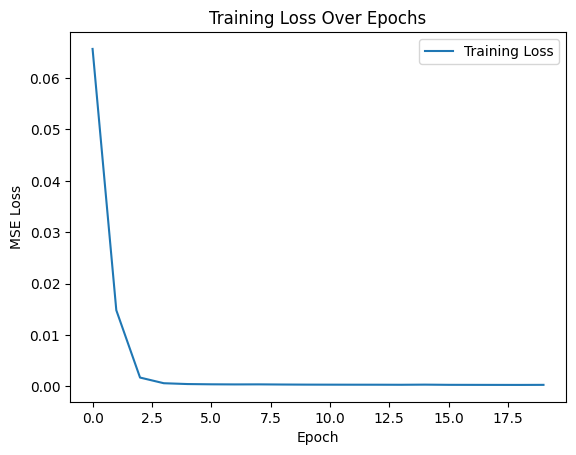

In [ ]:
print('Name: Thirunavukkarasu meenakshisundaram')
print('Register Number:212224220117')
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

Name: Thirunavukkarasu meenakshisundaram
Register Number:212224220117


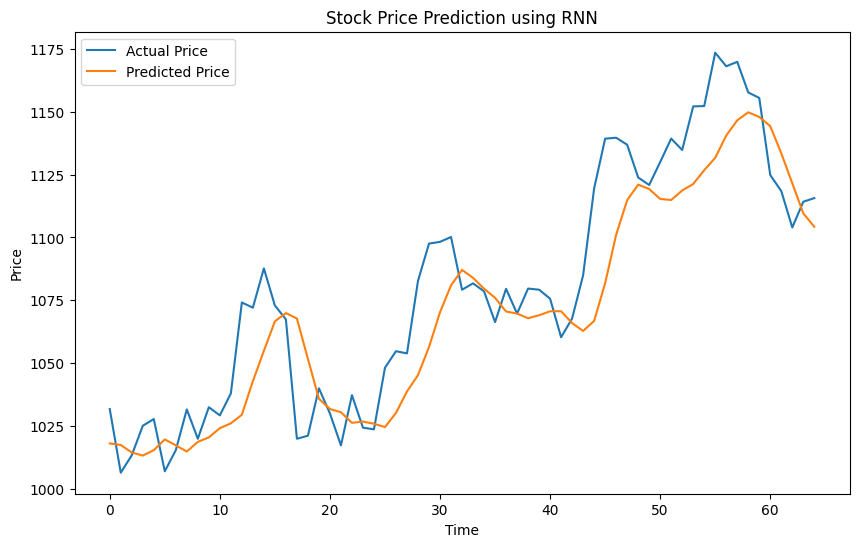

Predicted Price: [1104.2527]
Actual Price: [1115.65]


In [ ]:
model.eval()
with torch.no_grad():
    predicted = model(x_test_tensor.to(device)).cpu().numpy()
    actual = y_test_tensor.cpu().numpy()
predicted_prices = scaler.inverse_transform(predicted)
actual_prices = scaler.inverse_transform(actual)
print('Name: Thirunavukkarasu meenakshisundaram')
print('Register Number:212224220117')
plt.figure(figsize=(10, 6))
plt.plot(actual_prices, label='Actual Price')
plt.plot(predicted_prices, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.title('Stock Price Prediction using RNN')
plt.legend()
plt.show()
print(f'Predicted Price: {predicted_prices[-1]}')
print(f'Actual Price: {actual_prices[-1]}')